In [1]:
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

import numpy as np
import pandas as pd
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression

simplefilter("ignore")  # ignore warnings to clean up output cells

# Set Matplotlib defaults
sns.set_style('whitegrid')
plt.rc("figure", autolayout=True, figsize=(18, 7))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

In [2]:
data_dir = Path("../../Time Series/store-sales-time-series-forecasting")
oil = pd.read_csv(data_dir / "oil.csv", parse_dates=["date"])
oil = oil.set_index("date").to_period()

In [3]:
oil.isnull().sum()

dcoilwtico    43
dtype: int64

In [4]:
oil_copy = oil.copy()

oil_copy['dcoilwtico'].fillna(oil_copy['dcoilwtico'].median(), inplace=True)

oil_copy.head()

,dcoilwtico
date,
2013-01-01,53.19
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-07,93.20


<Axes: title={'center': 'Moving average for dcoilwtico for 365 days'}, xlabel='date'>

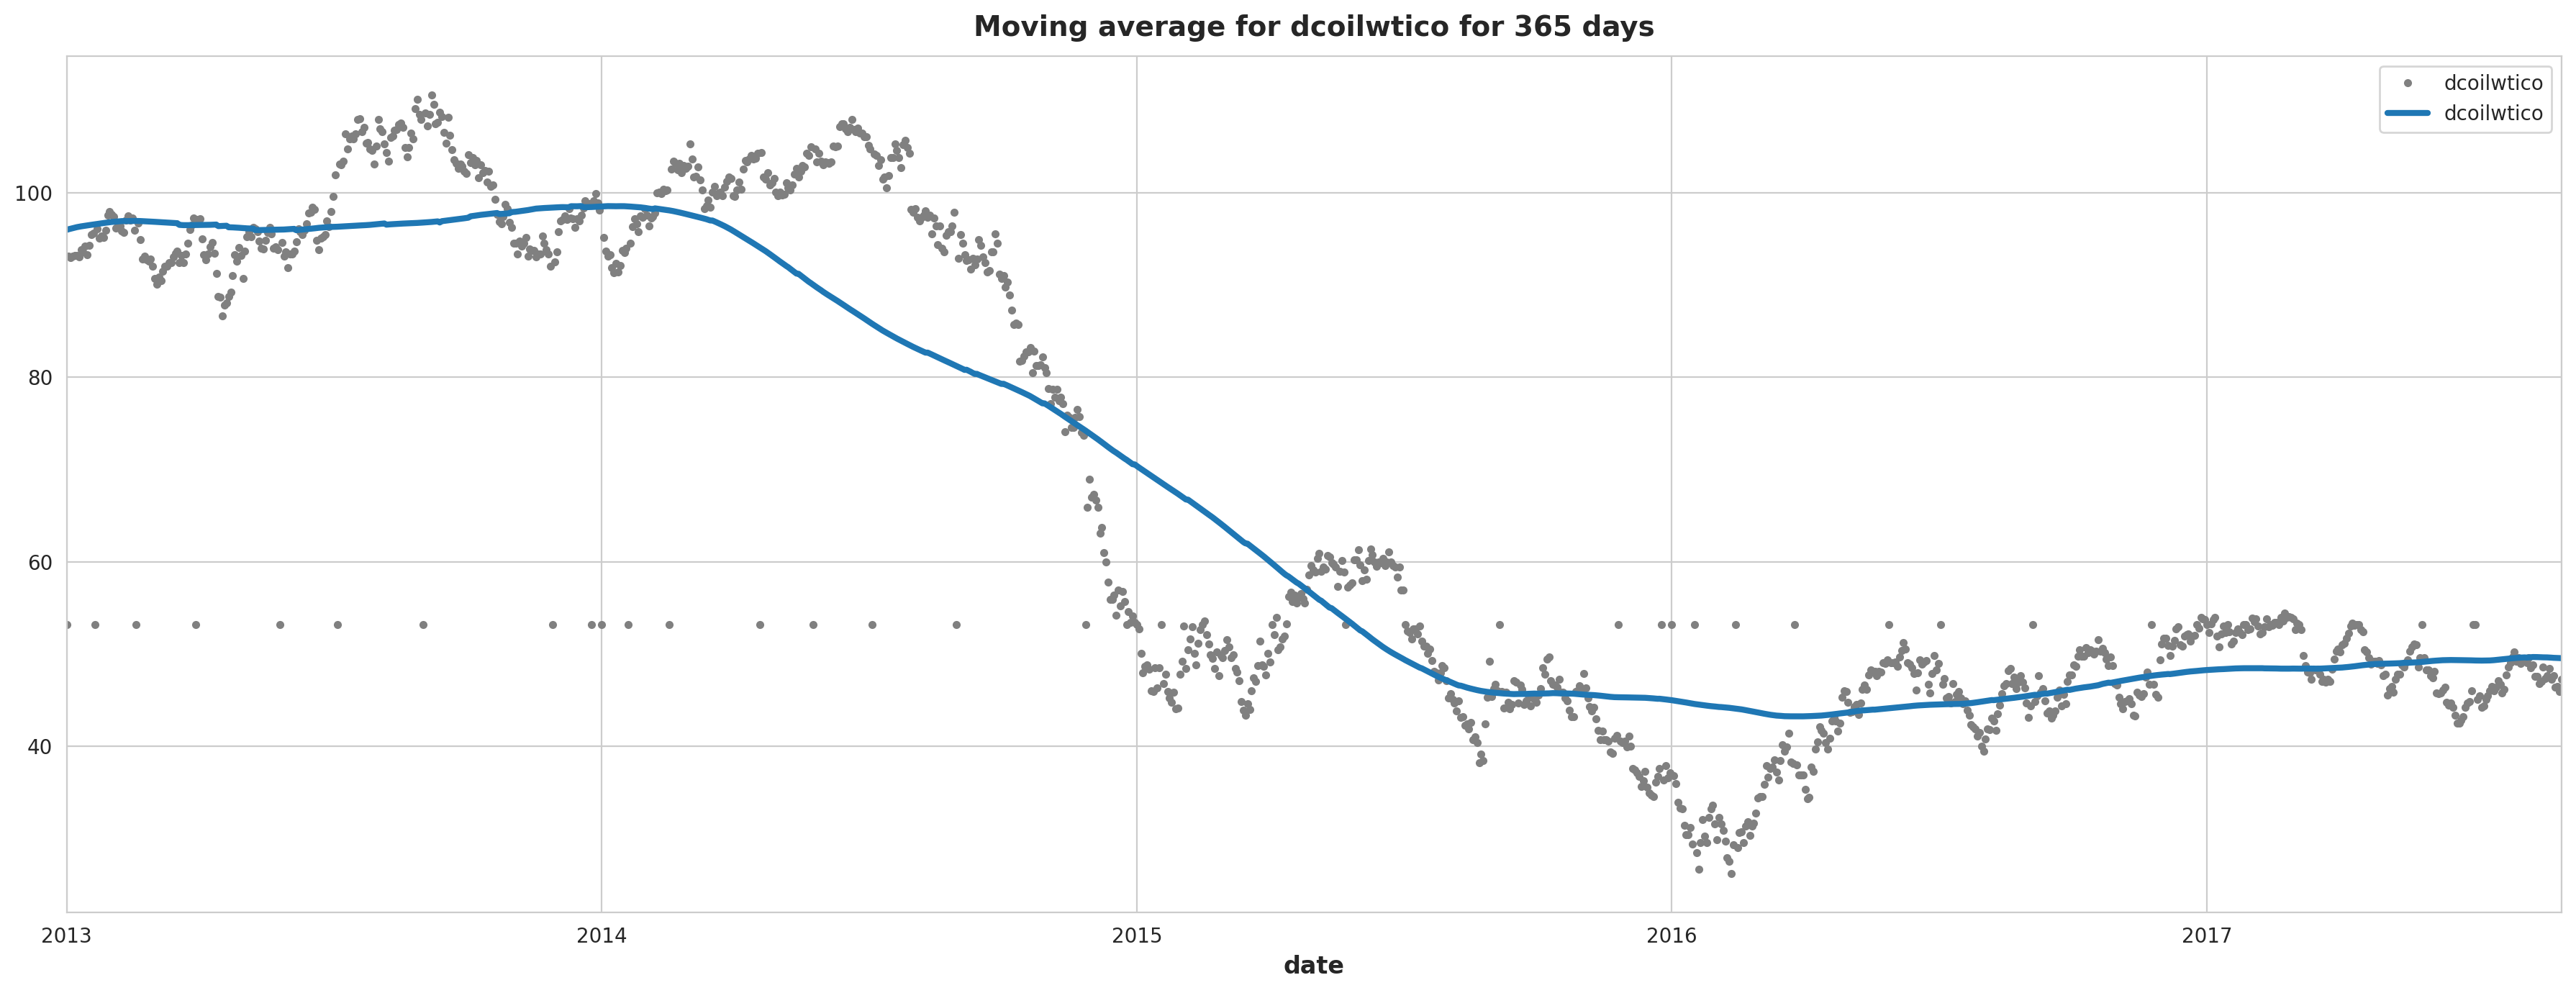

In [5]:
moving_average = oil_copy.rolling(
    window=365,
    center=True,
    min_periods=183
).mean()

ax = oil_copy.plot(style=".", color='0.5')
moving_average.plot(
    ax=ax, linewidth=3, title="Moving average for dcoilwtico for 365 days", legend=True
)

We'll use a function from the `statsmodels` library called `DeterministicProcess`. Using this function will help us avoid some tricky failure cases that can arise with time series and linear regression. The `order` argument refers to polynomial order: `1` for linear, `2` for quadratic, `3` for cubic, and so on.

In [6]:
dp = DeterministicProcess(
    index=oil_copy.index,
    constant=True,
    order=1,
    drop=True
)

X = dp.in_sample()

X.head()

,const,trend
date,,
2013-01-01,1.0,1.0
2013-01-02,1.0,2.0
2013-01-03,1.0,3.0
2013-01-04,1.0,4.0
2013-01-07,1.0,5.0


The trend discovered by our `LinearRegression` model is almost identical to the moving average plot, which suggests that a linear trend is the right decision in this case.

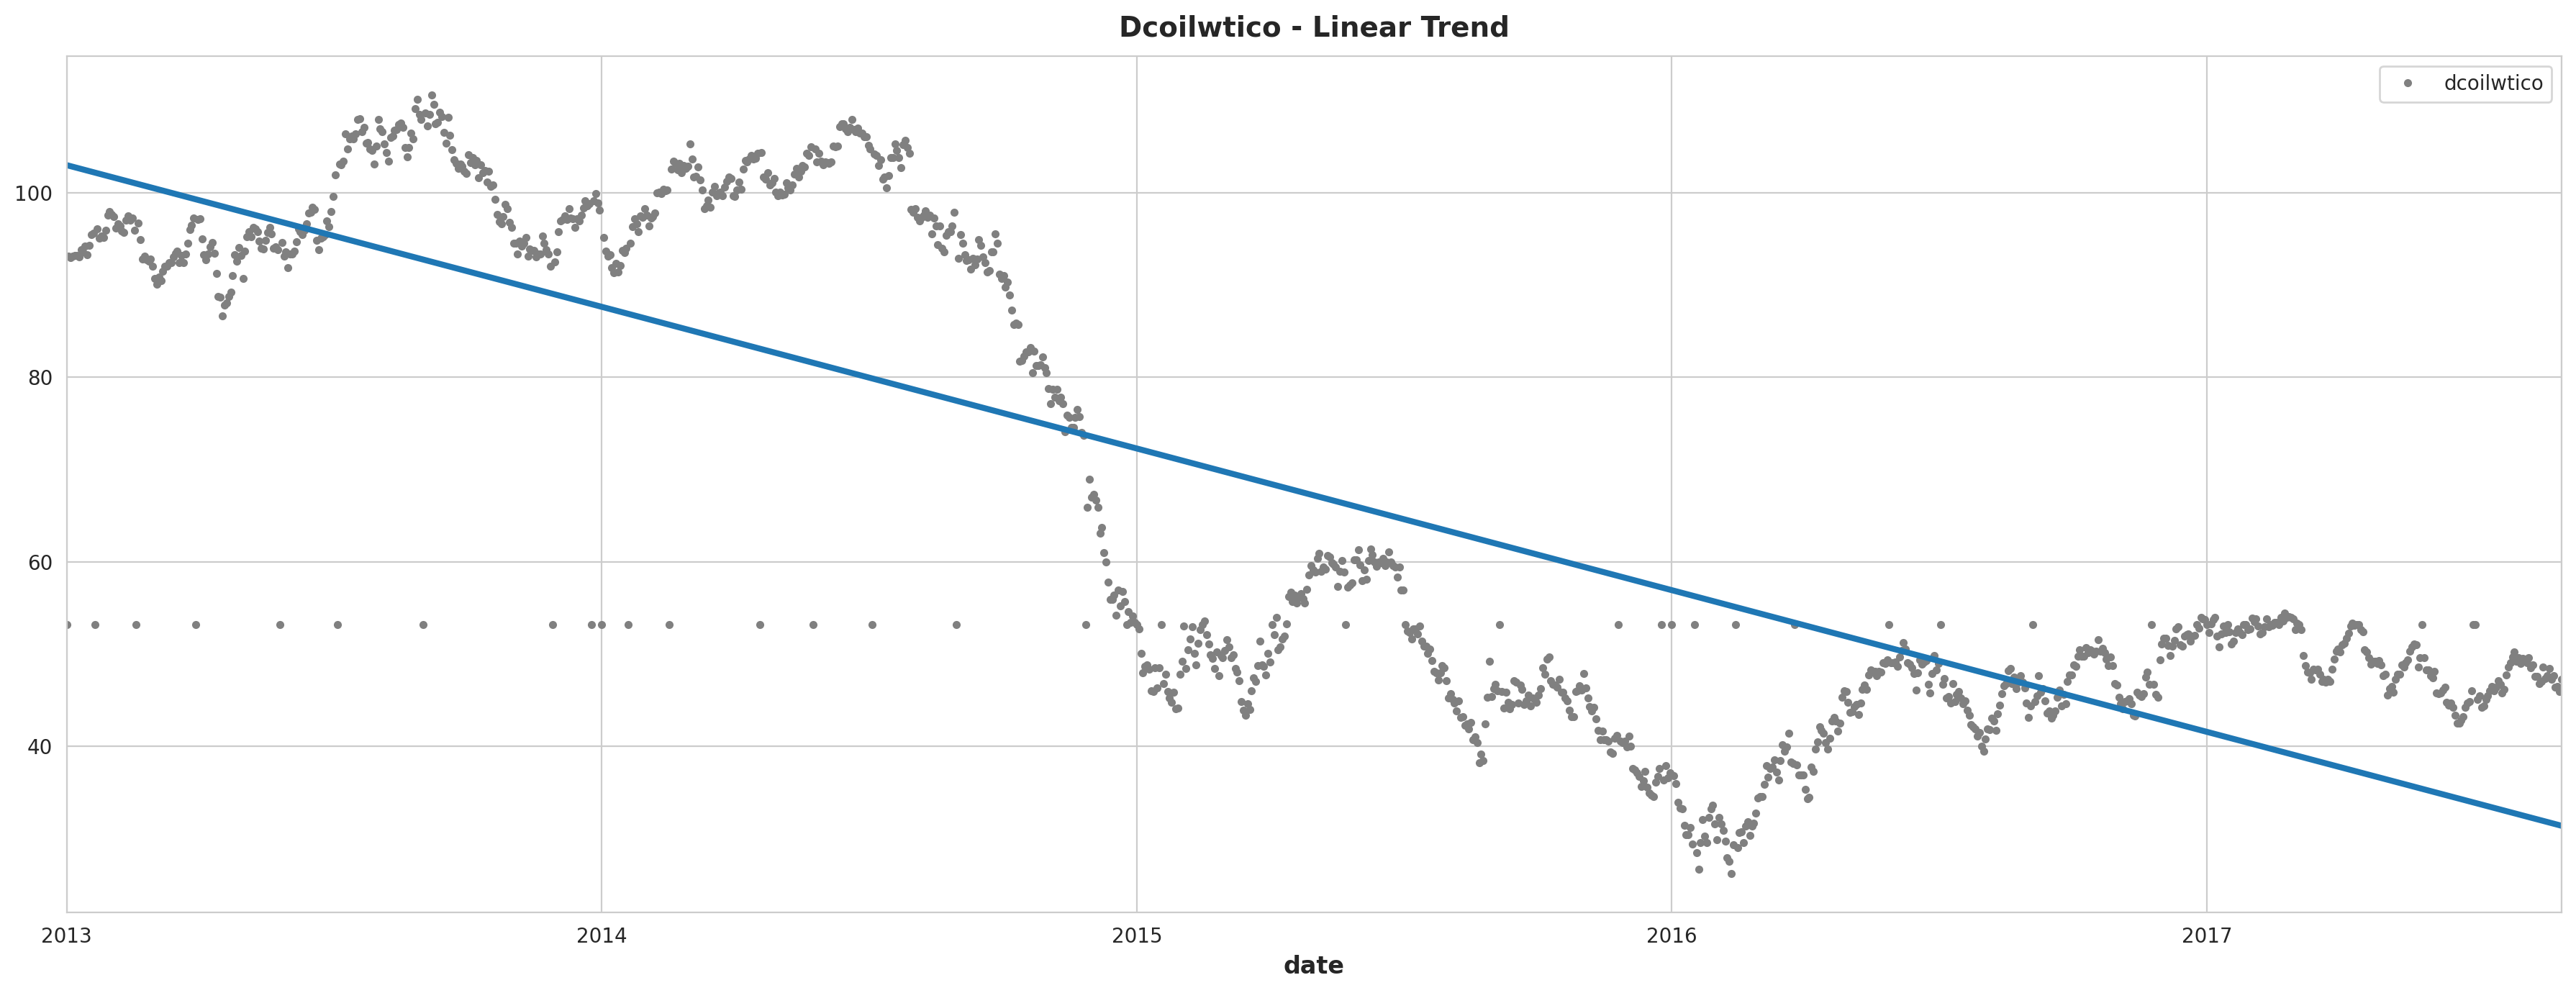

In [7]:
y = oil_copy['dcoilwtico']

model = LinearRegression(fit_intercept=True)
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

ax = oil_copy.plot(style='.', color='0.5', title='Dcoilwtico - Linear Trend')
_ = y_pred.plot(ax=ax, linewidth=3, label="Trend")

To make a forecast, we apply our model to "out of sample" features. "Out of sample" refers to times outside of the observation period of the training data. Here's how we could make a 30-day forecast

In [8]:
X = dp.out_of_sample(steps=60)

y_forecast = pd.Series(model.predict(X), index=X.index)

y_forecast.head()

2017-09-01    31.334956
2017-09-04    31.276110
2017-09-05    31.217264
2017-09-06    31.158418
2017-09-07    31.099572
Freq: B, dtype: float64

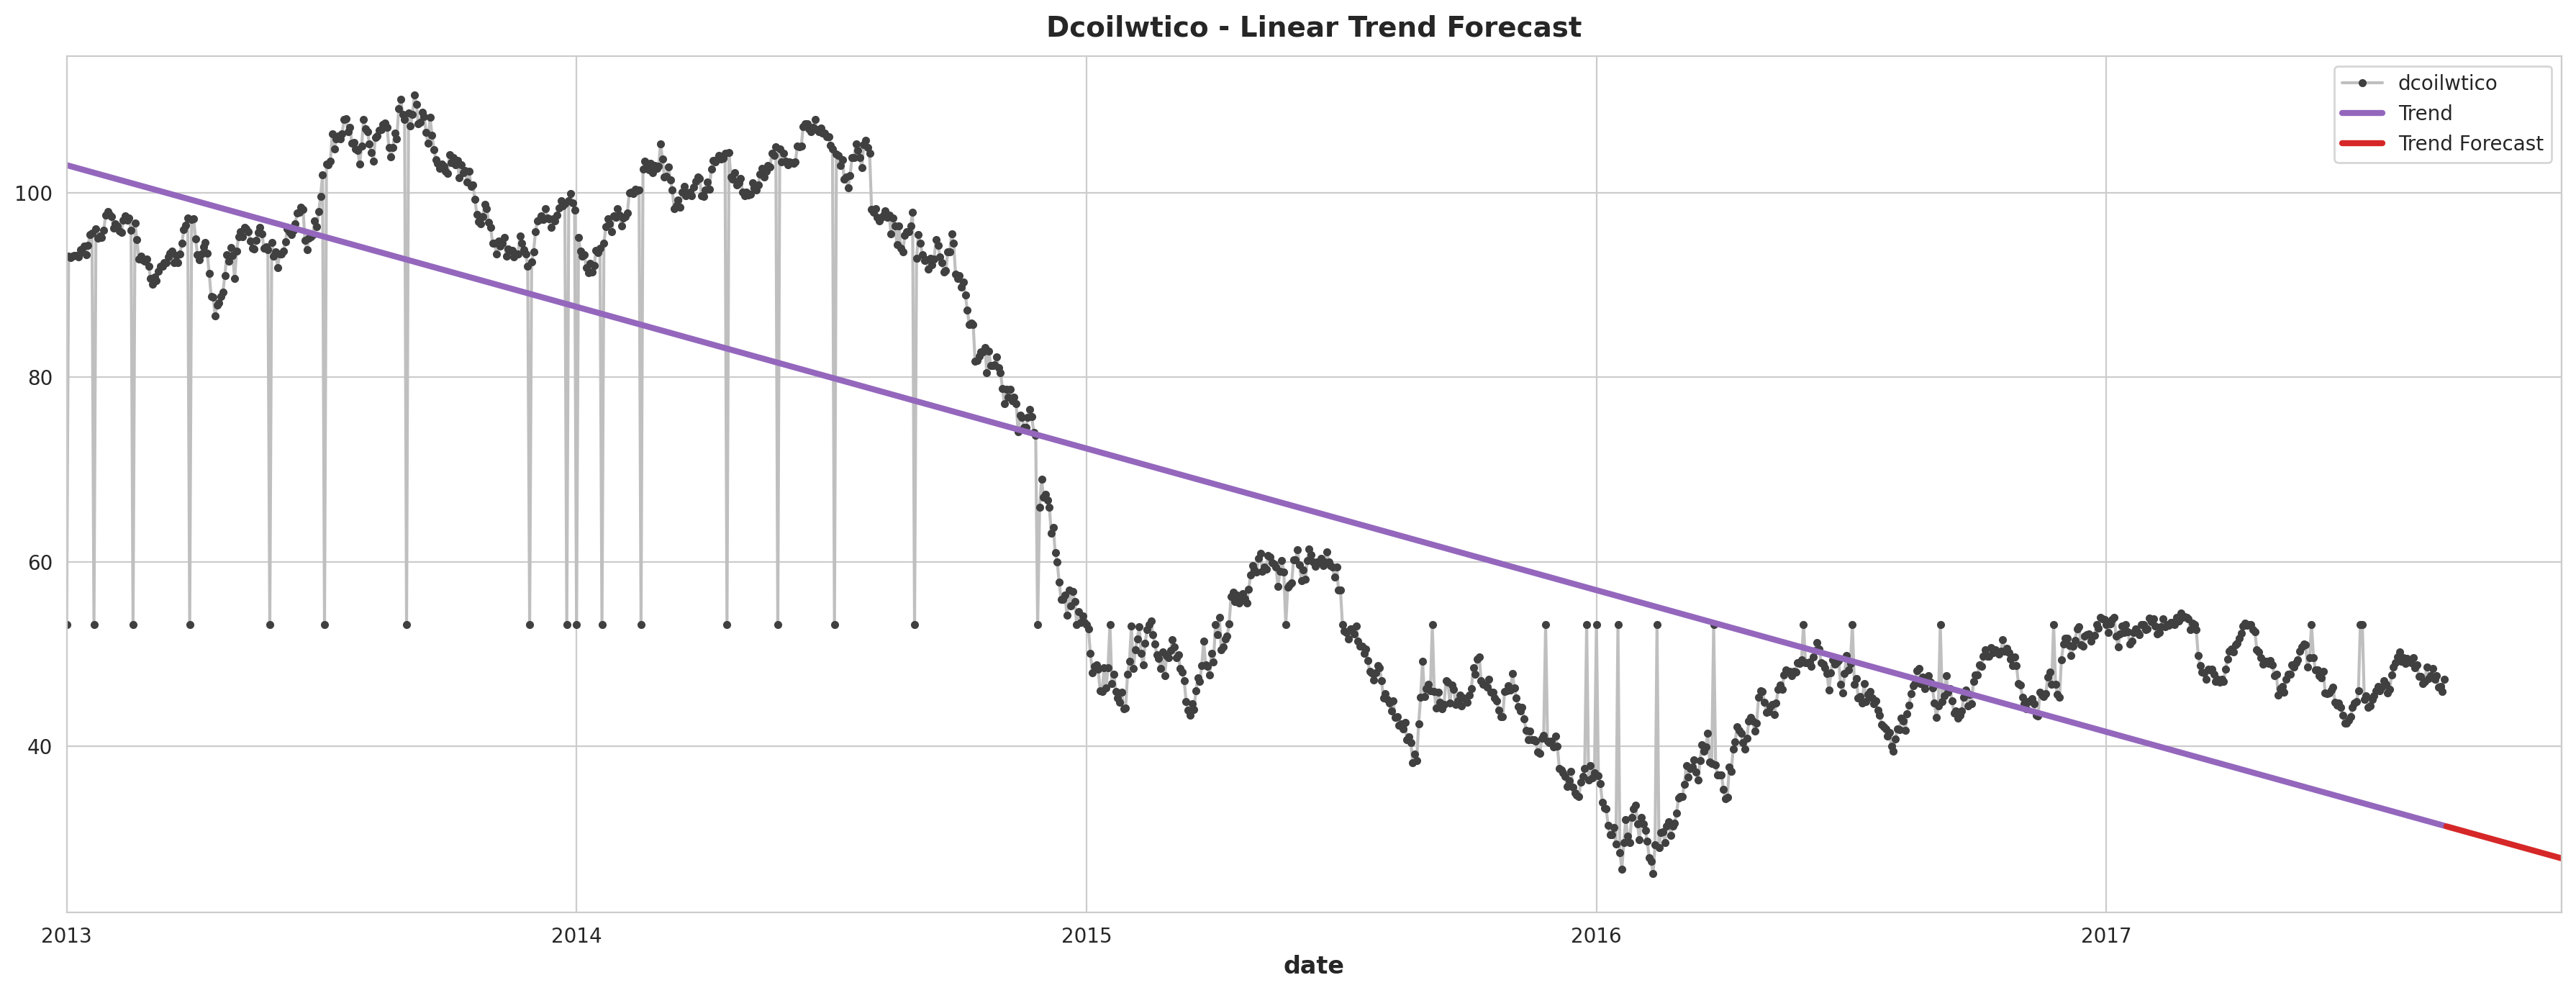

In [9]:
ax = oil_copy.plot(**plot_params, title="Dcoilwtico - Linear Trend Forecast")
ax = y_pred.plot(ax=ax, linewidth=3, label='Trend', color='C4')
ax = y_forecast.plot(ax=ax, linewidth=3, label="Trend Forecast", color='C3')
_ = ax.legend()

In [10]:
# Convert PeriodIndex to DatetimeIndex if necessary (in your case, already DatetimeIndex)
if isinstance(oil_copy.index, pd.PeriodIndex):
    oil_copy.index = oil_copy.index.to_timestamp()

if isinstance(y_forecast.index, pd.PeriodIndex):
    y_forecast.index = y_forecast.index.to_timestamp()

if isinstance(y_pred.index, pd.PeriodIndex):
    y_pred.index = y_pred.index.to_timestamp()

In [11]:
# Create the interactive plot
fig = go.Figure()

# Add the original oil prices
fig.add_trace(go.Scatter(
    x=oil_copy.index, y=oil_copy.values,
    mode='lines', name='Dcoilwtico',
    line=dict(color='blue')
))

# Add the linear trend
fig.add_trace(go.Scatter(
    x=y_pred.index, y=y_pred.values,
    mode='lines', name='Trend',
    line=dict(color='red', width=3)
))

# Add the trend forecast
fig.add_trace(go.Scatter(
    x=y_forecast.index, y=y_forecast.values,
    mode='lines', name='Trend Forecast',
    line=dict(color='green', width=3)
))

# Customize layout
fig.update_layout(
    title="Dcoilwtico - Linear Trend Forecast",
    xaxis_title="Date",
    yaxis_title="Value",
    legend_title="Legend",
    template="plotly_white"
)

# Show the interactive plot
fig.show()